# Organoid Knowledge Graph — One-Stop User Notebook

**Load, explore, and query the organoid culture database knowledge graph.**

This notebook covers the complete usage pipeline:
1. **Setup** — imports, configuration, dependency check
2. **Load & Statistics** — load a pre-built KG, visualize node/edge distributions
3. **Keyword Search** — search nodes by keyword, with optional type filtering
4. **Graph Traversal** — BFS traversal, path finding, subgraph visualization
5. **GraphRAG Q&A** — LLM-powered question answering over the knowledge graph
6. **Appendix** — node/relationship type reference, troubleshooting

## Prerequisites

```bash
pip install -r scripts/requirements.txt
pip install matplotlib networkx pandas  # optional — for visualization
```

## Before You Start

Make sure you have a knowledge graph file (`organoid_kg.json` or `organoid_kg.sqlite`) in the `organoid-kg-output/` directory. The notebook will auto-detect the latest one.

**Estimated runtime:** Loading ~30s, everything else instant (except LLM calls).

In [1]:
# ── Standard library ──
import json, os, sys, hashlib, datetime, time, textwrap
from collections import Counter, defaultdict
from pprint import pprint

# ── Add scripts/ to path so we can import project modules ──
_scripts_dir = os.path.join(os.getcwd(), "scripts")
if _scripts_dir not in sys.path:
    sys.path.insert(0, _scripts_dir)

# ── Core project imports ──
from query_tool import KnowledgeGraphQuery, GraphNode, GraphEdge

# ── Optional imports (graceful fallback) ──
def _safe_import(package, install_name=None):
    """Try to import a package; return (module, True) or (None, False) with install hint."""
    if install_name is None:
        install_name = package
    try:
        mod = __import__(package)
        return mod, True
    except ImportError:
        return None, False

matplotlib,    HAS_MATPLOTLIB = _safe_import("matplotlib")
plt_mod,       _ = _safe_import("matplotlib.pyplot")
networkx,      HAS_NETWORKX  = _safe_import("networkx")
np,            HAS_NUMPY     = _safe_import("numpy")
pd,            HAS_PANDAS    = _safe_import("pandas")
IPy_display,   HAS_IPYTHON   = _safe_import("IPython.display")

if HAS_MATPLOTLIB:
    import matplotlib.pyplot as plt
    # Configure for CJK-capable fonts (if available)
    for font in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "WenQuanYi Micro Hei", "DejaVu Sans"]:
        try:
            plt.rcParams["font.sans-serif"] = [font] + plt.rcParams["font.sans-serif"]
            break
        except Exception:
            pass
    plt.rcParams["axes.unicode_minus"] = False

if HAS_NETWORKX:
    import networkx as nx

if HAS_IPYTHON:
    from IPython.display import display, Markdown, HTML

print("[OK] Core imports (query_tool ready)")
print(f"  matplotlib:  {'[OK]' if HAS_MATPLOTLIB else '[MISSING] (optional - pip install matplotlib)'}")
print(f"  networkx:    {'[OK]' if HAS_NETWORKX  else '[MISSING] (optional - pip install networkx)'}")
print(f"  pandas:      {'[OK]' if HAS_PANDAS    else '[MISSING] (optional - pip install pandas)'}")
print(f"  IPython:     {'[OK]' if HAS_IPYTHON   else '[MISSING] (optional)'}")


[OK] Core imports (query_tool ready)
  matplotlib:  [OK]
  networkx:    [OK]
  pandas:      [OK]
  IPython:     [OK]


In [5]:
# Print a summary of which optional features are available
deps_status = [
    ("matplotlib", HAS_MATPLOTLIB, "Bar charts, subgraph visualization"),
    ("networkx",   HAS_NETWORKX,  "Graph layout, subgraph rendering"),
    ("pandas",     HAS_PANDAS,    "Rich DataFrames for search results"),
    ("IPython",    HAS_IPYTHON,   "Markdown/HTML display helpers"),
]
print(f"{'Package':<14} {'Status':<10} Feature")
print("-" * 60)
for pkg, ok, feature in deps_status:
    status = "✓ installed" if ok else "✗ missing"
    print(f"{pkg:<14} {status:<10} {feature}")

missing = [p for p, ok, _ in deps_status if not ok]
if missing:
    print(f"\nTo install missing packages:  pip install {' '.join(missing)}")
else:
    print("\n✓ All optional packages available. Full visualization support enabled.")


Package        Status     Feature
------------------------------------------------------------
matplotlib     ✓ installed Bar charts, subgraph visualization
networkx       ✓ installed Graph layout, subgraph rendering
pandas         ✓ installed Rich DataFrames for search results
IPython        ✓ installed Markdown/HTML display helpers

✓ All optional packages available. Full visualization support enabled.


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                        CONFIGURATION HUB                                    ║
# ║  Edit these values before running the notebook.                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# --- Knowledge Graph File Paths ---
KG_OUTPUT_DIR   = "./organoid-kg-output"
KG_JSON_PATH    = None          # Set to a specific .json path, or None to auto-detect
KG_SQLITE_PATH  = None          # Set to a specific .sqlite path, or None to auto-detect

# --- LLM API Configuration (for GraphRAG Q&A in Section 5) ---
LLM_API_KEY  = "sk-xxx"               # API key, or set env vars OPENAI_API_KEY / DEEPSEEK_API_KEY
LLM_BASE_URL = "https://api.deepseek.com"
LLM_MODEL    = "deepseek-v4-pro"

# --- Search & Traversal Defaults ---
DEFAULT_TOP_K           = 20
DEFAULT_TRAVERSAL_DEPTH = 2
DEFAULT_MAX_SAMPLES     = 30

# --- Visualization ---
VIZ_FIG_SIZE           = (12, 6)
VIZ_TOP_N             = 15
VIZ_MAX_SUBGRAPH_NODES = 50

print(f"✓ KG output directory: {os.path.abspath(KG_OUTPUT_DIR)}")
if not LLM_API_KEY:
    print("⚠  LLM_API_KEY is empty. GraphRAG Q&A (Section 4) requires an API key.")
    print("   Set LLM_API_KEY or the DEEPSEEK_API_KEY / OPENAI_API_KEY environment variable.")


✓ KG output directory: D:\PycharmProjects\pub_database\build_graphRAG\organoid-kg-output


---
## Section 1: Load Knowledge Graph & Explore Statistics

Load the knowledge graph from a file (JSON or SQLite) and explore its structure —
node types, relationship types, and key entities.

In [7]:
# Cell 1.1 — Auto-detect or specify the KG file to load
def _find_latest_kg(base_dir):
    """Scan timestamped subdirectories for the latest organoid_kg.json."""
    if not os.path.isdir(base_dir):
        return None
    subdirs = []
    for name in os.listdir(base_dir):
        full = os.path.join(base_dir, name)
        if os.path.isdir(full):
            # Match YYYY-MM-DD-HHMM pattern
            parts = name.split("-")
            if len(parts) >= 4 and all(p.isdigit() for p in parts[:4]):
                kg_file = os.path.join(full, "organoid_kg.json")
                if os.path.isfile(kg_file):
                    subdirs.append((name, kg_file))
    if not subdirs:
        return None
    subdirs.sort(key=lambda x: x[0], reverse=True)
    return subdirs[0][1]

# Determine LOAD_PATH
LOAD_PATH = None
source = ""

# Priority 1: explicit config
if KG_JSON_PATH and os.path.isfile(KG_JSON_PATH):
    LOAD_PATH = KG_JSON_PATH
    source = "KG_JSON_PATH config"
elif KG_SQLITE_PATH and os.path.isfile(KG_SQLITE_PATH):
    LOAD_PATH = KG_SQLITE_PATH
    source = "KG_SQLITE_PATH config"

# Priority 2: auto-detect from output directory
if LOAD_PATH is None:
    LOAD_PATH = _find_latest_kg(KG_OUTPUT_DIR)
    if LOAD_PATH:
        source = f"auto-detected in {KG_OUTPUT_DIR}"

if LOAD_PATH:
    size_mb = os.path.getsize(LOAD_PATH) / (1024 * 1024)
    print(f"KG file: {LOAD_PATH}")
    print(f"Source:  {source}")
    print(f"Size:    {size_mb:.1f} MB")
else:
    print("⚠  No KG file found.")
    print("   Options:")
    print(f"   1. Set KG_JSON_PATH or KG_SQLITE_PATH in the Configuration cell")
    print(f"   2. Place a .json or .sqlite file under {KG_OUTPUT_DIR}")
    print(f"   3. Run build_kg.py to construct a new KG from the database")


KG file: ./organoid-kg-output\2026-07-19-1138\organoid_kg.json
Source:  auto-detected in ./organoid-kg-output
Size:    534.7 MB


In [8]:
# Cell 1.2 — Load the knowledge graph into memory
if LOAD_PATH is not None:
    print(f"Loading KG from: {LOAD_PATH}")
    print("(Large JSON files may take 30-60 seconds; SQLite is faster)\n")
    try:
        t0 = time.time()
        kg = KnowledgeGraphQuery.load(LOAD_PATH)
        elapsed = time.time() - t0
        print(f"✓ Loaded in {elapsed:.1f}s")
        print(f"  Nodes: {len(kg.nodes):,}  |  Edges: {len(kg.edges):,}")
        print(f"  Node types: {len(kg._type_index)}  |  Memory footprint: ~{len(kg.nodes) * 0.5:.0f} KB estimated")
    except MemoryError:
        print("[ERROR] Not enough memory to load the JSON file.")
        print("[HINT] Use the SQLite format instead — it loads incrementally:")
        print("       Set KG_SQLITE_PATH in the Configuration cell.")
    except FileNotFoundError:
        print(f"[ERROR] File not found: {LOAD_PATH}")
    except Exception as e:
        print(f"[ERROR] {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
else:
    print("LOAD_PATH is not set. Run Cell 1.1 first.")
    kg = None


Loading KG from: ./organoid-kg-output\2026-07-19-1138\organoid_kg.json
(Large JSON files may take 30-60 seconds; SQLite is faster)

[OK] Loaded knowledge graph: 103360 nodes, 258284 edges
✓ Loaded in 16.0s
  Nodes: 103,360  |  Edges: 258,284
  Node types: 18  |  Memory footprint: ~51680 KB estimated


In [9]:
# Cell 1.3 — Print knowledge graph statistics
if kg is not None:
    kg.print_stats()

    stats = kg.stats()
    print(f"\nAdditional metrics:")
    print(f"  Average degree:  {stats['avg_degree']:.2f}")
    print(f"  Max degree:      {stats['max_degree']}")
    print(f"  Isolated nodes:  {stats['isolated_nodes']}")
else:
    print("KG not loaded. Run Cell 1.2 first.")



  Knowledge Graph Statistics
  Total nodes:         103360
  Total edges:         258284
  Average degree:        5.00
  Max degree:           16104
  Isolated nodes:           1

  Nodes by type:
    Phenotype                :  17984
    Sample                   :  17055
    Technology               :  15869
    Publication              :  12473
    Composition              :  10518
    Organoid                 :   9095
    Drug                     :   4255
    Biomarker                :   4193
    DiseaseModel             :   4038
    CellFactor               :   2848
    Application              :   1453
    Gene                     :   1333
    Infection                :    959
    Organ                    :    601
    System                   :    243
    Omics                    :    226
    Source                   :    120
    Organism                 :     97

  Edges by relation:
    HAS_BIOMARKER            :  29568
    USES_FACTOR              :  25974
    HAS_COMPOSITION 

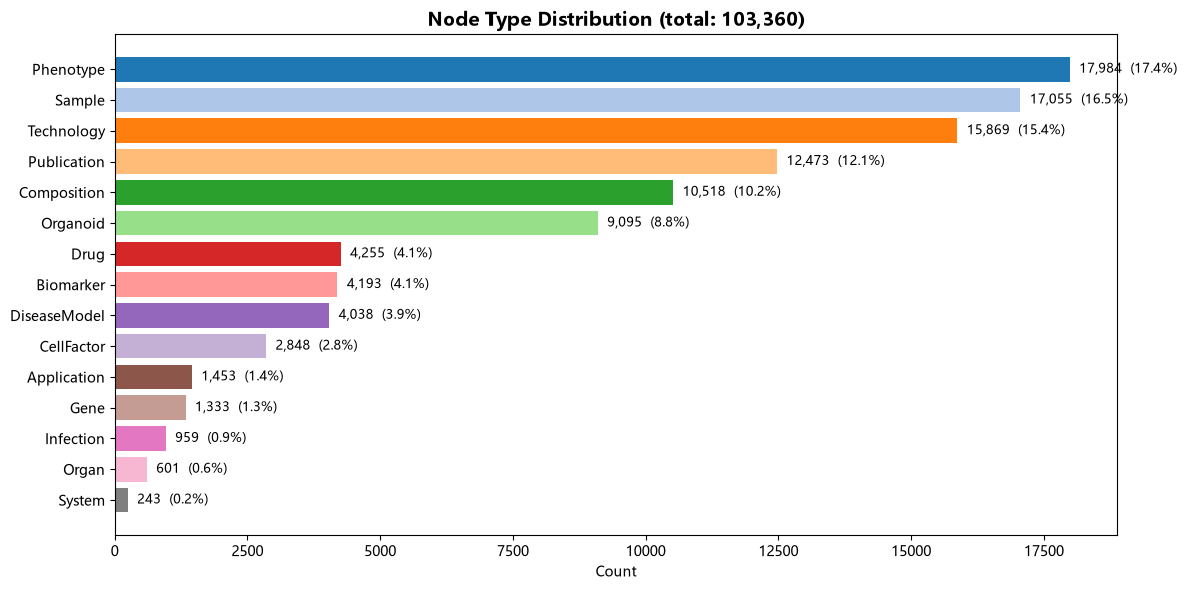

In [10]:
# Cell 1.4 — Visualize node type distribution
def plot_node_type_distribution(node_type_counts, top_n=15, figsize=(12, 6)):
    """Horizontal bar chart of node type distribution."""
    if not HAS_MATPLOTLIB:
        print("matplotlib not installed. Install with: pip install matplotlib")
        # Fallback: text table
        print(f"\n{'Node Type':<20} {'Count':>8} {'Pct':>8}")
        print("-" * 40)
        total = sum(node_type_counts.values())
        for t, c in sorted(node_type_counts.items(), key=lambda x: -x[1])[:top_n]:
            print(f"{t:<20} {c:>8,} {c/total*100:>7.1f}%")
        return

    items = sorted(node_type_counts.items(), key=lambda x: -x[1])[:top_n]
    types, counts = zip(*items)
    total = sum(node_type_counts.values())

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab20(range(len(types)))
    bars = ax.barh(range(len(types)), counts, color=colors)

    ax.set_yticks(range(len(types)))
    ax.set_yticklabels(types)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(f"Node Type Distribution (total: {total:,})", fontsize=14, fontweight="bold")

    for i, (t, c) in enumerate(zip(types, counts)):
        pct = c / total * 100
        ax.text(c + max(counts) * 0.01, i, f"{c:,}  ({pct:.1f}%)", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

if kg is not None:
    plot_node_type_distribution(kg.stats()["nodes_by_type"], top_n=VIZ_TOP_N, figsize=VIZ_FIG_SIZE)
else:
    print("KG not loaded. Run Cell 1.2 first.")


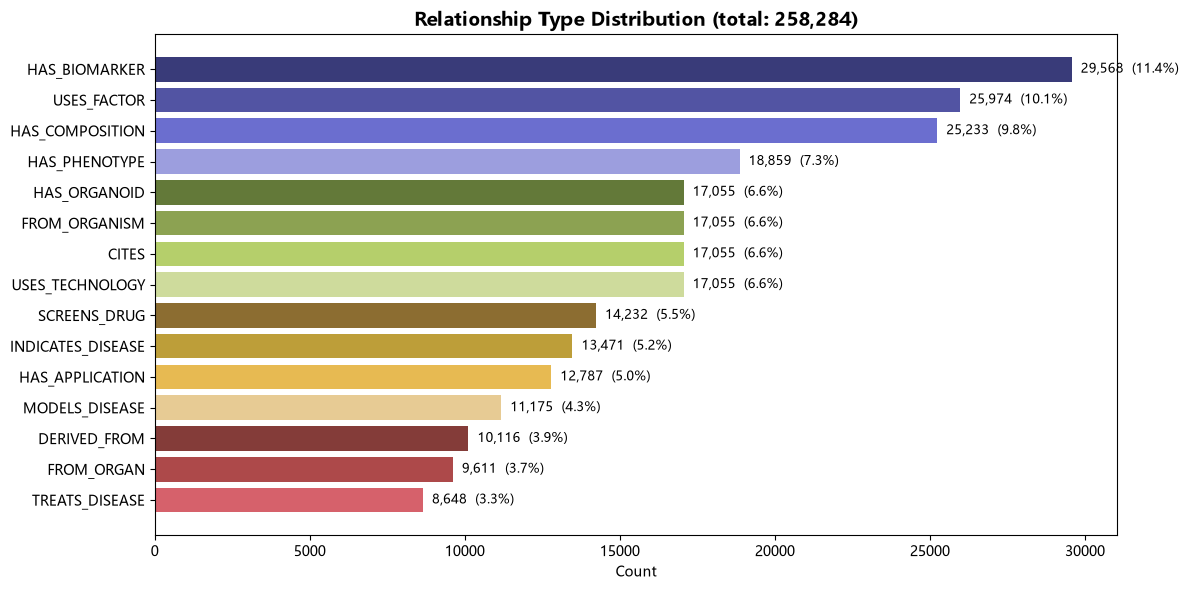

In [11]:
# Cell 1.5 — Visualize relationship type distribution
def plot_relation_distribution(edge_type_counts, top_n=15, figsize=(12, 6)):
    """Horizontal bar chart of relationship type distribution."""
    if not HAS_MATPLOTLIB:
        total = sum(edge_type_counts.values())
        print(f"{'Relation':<25} {'Count':>8} {'Pct':>8}")
        print("-" * 45)
        for r, c in sorted(edge_type_counts.items(), key=lambda x: -x[1])[:top_n]:
            print(f"{r:<25} {c:>8,} {c/total*100:>7.1f}%")
        return

    items = sorted(edge_type_counts.items(), key=lambda x: -x[1])[:top_n]
    relations, counts = zip(*items)
    total = sum(edge_type_counts.values())

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab20b(range(len(relations)))
    bars = ax.barh(range(len(relations)), counts, color=colors)

    ax.set_yticks(range(len(relations)))
    ax.set_yticklabels(relations)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(f"Relationship Type Distribution (total: {total:,})", fontsize=14, fontweight="bold")

    for i, (r, c) in enumerate(zip(relations, counts)):
        pct = c / total * 100
        ax.text(c + max(counts) * 0.01, i, f"{c:,}  ({pct:.1f}%)", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

if kg is not None:
    plot_relation_distribution(kg.stats()["edges_by_relation"], top_n=VIZ_TOP_N, figsize=VIZ_FIG_SIZE)
else:
    print("KG not loaded. Run Cell 1.2 first.")


In [12]:
# Cell 1.6 — Top-5 most-connected entities by major type
if kg is not None:
    major_types = ["Organoid", "Drug", "CellFactor", "Gene", "DiseaseModel", "Biomarker", "Technology"]
    print(f"{'Type':<16} {'Degree':>6}  {'Name':<40}  ID")
    print("-" * 90)
    for ntype in major_types:
        # Get all node IDs of this type
        node_ids = kg._type_index.get(ntype, [])
        if not node_ids:
            continue
        # Compute degree from adjacency
        scored = []
        for nid in node_ids:
            degree = len(kg._adjacency.get(nid, []))
            scored.append((degree, nid))
        scored.sort(key=lambda x: -x[0])
        for rank, (degree, nid) in enumerate(scored[:5]):
            node = kg.nodes[nid]
            name = node.properties.get("name", nid)[:40]
            marker = "←" if rank == 0 else " "
            print(f"  {marker} {ntype:<14} {degree:>6}  {name:<40}  {nid}")
        print()
else:
    print("KG not loaded. Run Cell 1.2 first.")


Type             Degree  Name                                      ID
------------------------------------------------------------------------------------------
  ← Organoid          730  Cerebral Organoid                         org_3e906e7d
    Organoid          642  Intestinal Organoid                       org_3a525151
    Organoid          640  Small Intestinal Organoid                 org_8bfdd6b0
    Organoid          407  Retinal Organoid                          org_e9a6a9be
    Organoid          317  Kidney Organoid                           org_2133c65c

  ← Drug              670  cisplatin                                 drg_492d36f2
    Drug              403  paclitaxel                                drg_74546d3d
    Drug              377  gemcitabine                               drg_e222d1c4
    Drug              353  Oxaliplatin                               drg_f00be86b
    Drug              324  doxorubicin                               drg_b3682bbc

  ← CellFactor   

---
## Section 2: Keyword Search & Query

The `kg.search()` method splits your query into space-separated keywords and scores
each node by the fraction of keywords matched (AND logic). You can optionally filter
by node type for targeted lookups.


In [14]:
# Cell 2.1 — Basic keyword search (5 demo queries)
if kg is not None:
    demo_queries = [
        "EGF Wnt R-spondin",
        "intestinal organoid",
        "Colorectal Cancer",
        "CRISPR",
        "Cisplatin",
    ]
    for query in demo_queries:
        results = kg.search(query, top_k=5)
        print(f"\n{'─' * 70}")
        print(f'Query: "{query}"  →  {len(results)} results')
        print(f"{'─' * 70}")
        for node, score in results[:5]:
            name = node.properties.get("name", node.properties.get("sample_id", node.id))
            name_str = str(name)[:55]
            print(f"  [{node.type:<15}] {name_str:<55}  score={score:.2f}  id={node.id}")
else:
    print("KG not loaded. Run Cell 1.2 first.")



──────────────────────────────────────────────────────────────────────
Query: "EGF Wnt R-spondin"  →  5 results
──────────────────────────────────────────────────────────────────────
  [Sample         ] KM-00002                                                 score=1.00  id=smp_KM-00002
  [Sample         ] KM-00005                                                 score=1.00  id=smp_KM-00005
  [Sample         ] KM-00045                                                 score=1.00  id=smp_KM-00045
  [Sample         ] KM-00063                                                 score=1.00  id=smp_KM-00063
  [Sample         ] KM-00088                                                 score=1.00  id=smp_KM-00088

──────────────────────────────────────────────────────────────────────
Query: "intestinal organoid"  →  5 results
──────────────────────────────────────────────────────────────────────
  [Sample         ] KM-00001                                                 score=1.00  id=smp_KM-00001


In [15]:
# Cell 2.2 — Type-filtered search
if kg is not None:
    def search_and_display(kg_obj, query, node_type, top_k=10):
        """Search with type filter and print formatted results."""
        results = kg_obj.search(query, node_type=node_type, top_k=top_k)
        print(f'\nSearch: "{query}"  [type={node_type}]')
        print(f"Results: {len(results)}")
        for node, score in results[:top_k]:
            name = node.properties.get("name", "?")
            extra = ""
            if "category" in node.properties:
                extra = f" | category: {node.properties['category']}"
            print(f"  [{node.type}] {name}{extra}  —  score={score:.2f}  id={node.id}")
        return results

    # Drug search
    search_and_display(kg, "Cisplatin", "Drug")
    # Biomarker search
    search_and_display(kg, "Lgr5", "Biomarker")
    # Gene search
    search_and_display(kg, "APC", "Gene")
    # Organ search
    search_and_display(kg, "Liver", "Organ")
else:
    print("KG not loaded. Run Cell 1.2 first.")



Search: "Cisplatin"  [type=Drug]
Results: 10
  [Drug] cisplatin  —  score=1.00  id=drg_492d36f2
  [Drug] CDDP (Cisplatin)  —  score=1.00  id=drg_c658c837
  [Drug] cisplatin (DDP)  —  score=1.00  id=drg_a4e0aad9
  [Drug] paclitaxel plus cisplatin (TP)  —  score=1.00  id=drg_3584b186
  [Drug] vinorelbine plus cisplatin (NP)  —  score=1.00  id=drg_58677f8b
  [Drug] 5-fluorouracil plus cisplatin (FP)  —  score=1.00  id=drg_2045f210
  [Drug] Cisplatin (CDDP)  —  score=1.00  id=drg_340a5fb0
  [Drug] irinotecan plus cisplatin  —  score=1.00  id=drg_ac015eed
  [Drug] kenpaullone  —  score=1.00  id=drg_42d80ce7
  [Drug] Tizanidine  —  score=1.00  id=drg_656e42af

Search: "Lgr5"  [type=Biomarker]
Results: 10
  [Biomarker] P53-dependent apoptosis  —  score=1.00  id=bmk_97b1507e
  [Biomarker] DNA damage response  —  score=1.00  id=bmk_83799cee
  [Biomarker] Apoptosis  —  score=1.00  id=bmk_56f54ad1
  [Biomarker] AP-1 family  —  score=1.00  id=bmk_53a157c3
  [Biomarker] Wnt signalling  —  score=1.

In [16]:
# Cell 2.3 — Explore a search result's neighborhood
if kg is not None:
    # Re-run a search to get a seed node
    seed_results = kg.search("EGF", top_k=1)
    if seed_results:
        seed_node, seed_score = seed_results[0]
        seed_name = seed_node.properties.get("name", seed_node.properties.get("sample_id", seed_node.id))
        print(f"Seed node: [{seed_node.type}] {seed_name}  (score={seed_score:.2f}, id={seed_node.id})\n")

        sub = kg.traverse(seed_node.id, depth=1)
        print(f"1-hop subgraph: {len(sub['nodes'])} nodes, {len(sub['edges'])} edges\n")

        # Group neighbors by type
        neighbors_by_type = defaultdict(list)
        for edge in sub["edges"]:
            if edge.source == seed_node.id:
                neighbor = kg.nodes.get(edge.target)
            elif edge.target == seed_node.id:
                neighbor = kg.nodes.get(edge.source)
            else:
                continue
            if neighbor and neighbor.id != seed_node.id:
                neighbors_by_type[neighbor.type].append((neighbor, edge.relation))

        for ntype, items in sorted(neighbors_by_type.items()):
            print(f"  [{ntype}] ({len(items)} connections):")
            for neighbor, rel in items[:5]:
                name = neighbor.properties.get("name", neighbor.id)
                print(f"    --[{rel}]--> {str(name)[:60]}")
            if len(items) > 5:
                print(f"    ... and {len(items) - 5} more")
            print()
    else:
        print("No search results found for 'EGF'. Try a different query.")
else:
    print("KG not loaded. Run Cell 1.2 first.")


Seed node: [Sample] KM-00002  (score=1.00, id=smp_KM-00002)

1-hop subgraph: 16 nodes, 23638 edges

  [Biomarker] (1 connections):
    --[HAS_BIOMARKER]--> organoid

  [CellFactor] (4 connections):
    --[USES_FACTOR]--> EGF
    --[USES_FACTOR]--> FGF2
    --[USES_FACTOR]--> R-spondin1-conditioned medium
    --[USES_FACTOR]--> Wnt3a-conditioned medium

  [Composition] (1 connections):
    --[HAS_COMPOSITION]--> salivary gland stem/progenitor cells

  [Drug] (2 connections):
    --[SCREENS_DRUG]--> Urolithin A
    --[SCREENS_DRUG]--> PMI

  [Organism] (1 connections):
    --[FROM_ORGANISM]--> Mus musculus

  [Organoid] (1 connections):
    --[HAS_ORGANOID]--> mouse salivary gland organoids

  [Phenotype] (3 connections):
    --[HAS_PHENOTYPE]--> increased senescence
    --[HAS_PHENOTYPE]--> accumulation of dysfunctional mitochondria
    --[HAS_PHENOTYPE]--> elongated mitochondria and denser mitochondrial network

  [Publication] (1 connections):
    --[CITES]--> 10.1016/j.radonc.2023.11

---
## Section 3: Graph Traversal & Path Finding

Graph traversal uses **BFS (breadth-first search)** to expand outward from a seed node.
Path finding discovers the shortest connecting routes between two arbitrary nodes.


In [17]:
# Cell 3.1 — Traverse from a sample node at different depths
if kg is not None:
    # Auto-select a sample node
    sample_ids = kg._type_index.get("Sample", [])
    if not sample_ids:
        print("No Sample nodes found in the KG.")
    else:
        sample_id = sample_ids[0]
        sample_node = kg.nodes[sample_id]
        sample_name = sample_node.properties.get("sample_id", sample_id)
        print(f"Sample node: {sample_name}  (id={sample_id})\n")

        for depth in [1, 2, 3]:
            sub = kg.traverse(sample_id, depth=depth)
            node_count = len(sub["nodes"])
            edge_count = len(sub["edges"])
            # Count types in subgraph
            type_counts = Counter(n.type for n in sub["nodes"])
            print(f"  depth={depth}: {node_count:,} nodes, {edge_count:,} edges  "
                  f"| types: {dict(type_counts)}")

        # Detailed 1-hop view
        print(f"\n{'─' * 60}")
        print("1-hop detail:")
        sub1 = kg.traverse(sample_id, depth=1)
        neighbors_by_type = defaultdict(list)
        for edge in sub1["edges"]:
            neighbor_id = edge.target if edge.source == sample_id else edge.source
            if neighbor_id != sample_id:
                neighbor = kg.nodes.get(neighbor_id)
                if neighbor:
                    neighbors_by_type[neighbor.type].append((neighbor, edge.relation))

        for ntype, items in sorted(neighbors_by_type.items()):
            print(f"\n  [{ntype}] ({len(items)}):")
            for neighbor, rel in items[:8]:
                name = neighbor.properties.get("name", neighbor.id)
                print(f"    --[{rel}]--> {str(name)[:60]}")
            if len(items) > 8:
                print(f"    ... and {len(items) - 8} more")
else:
    print("KG not loaded. Run Cell 1.2 first.")


Sample node: KM-00001  (id=smp_KM-00001)

  depth=1: 7 nodes, 20,082 edges  | types: {'Publication': 1, 'Organism': 1, 'Composition': 1, 'Organoid': 1, 'Technology': 1, 'Biomarker': 1, 'Sample': 1}
  depth=2: 16,905 nodes, 189,840 edges  | types: {'Sample': 13661, 'DiseaseModel': 3233, 'Application': 3, 'Organ': 1, 'Composition': 1, 'Organism': 1, 'Organoid': 1, 'Biomarker': 1, 'Source': 1, 'Technology': 1, 'Publication': 1}
  depth=3: 86,576 nodes, 244,163 edges  | types: {'Sample': 13661, 'Phenotype': 16156, 'Publication': 11043, 'Technology': 13005, 'Drug': 4083, 'Organoid': 8713, 'Infection': 850, 'Biomarker': 3288, 'CellFactor': 2628, 'DiseaseModel': 3233, 'Composition': 8459, 'Gene': 1166, 'Organism': 74, 'Omics': 205, 'System': 7, 'Application': 3, 'Source': 1, 'Organ': 1}

────────────────────────────────────────────────────────────
1-hop detail:

  [Biomarker] (3234):
    --[HAS_BIOMARKER]--> organoid
    --[INDICATES_DISEASE]--> organoid
    --[INDICATES_DISEASE]--> organoid


In [18]:
# Cell 3.2 — Find paths between two nodes
if kg is not None:
    # Auto-select: pick one Drug and one DiseaseModel
    drug_ids = kg._type_index.get("Drug", [])
    disease_ids = kg._type_index.get("DiseaseModel", [])

    if drug_ids and disease_ids:
        drug_id = drug_ids[0]
        disease_id = disease_ids[0]
        drug_name = kg.nodes[drug_id].properties.get("name", drug_id)
        disease_name = kg.nodes[disease_id].properties.get("name", disease_id)

        print(f"Finding paths:")
        print(f"  From: [{kg.nodes[drug_id].type}] {drug_name}")
        print(f"  To:   [{kg.nodes[disease_id].type}] {disease_name}\n")

        paths = kg.find_paths(drug_id, disease_id, max_length=4)
        print(f"Found {len(paths)} path(s):\n")

        for i, path in enumerate(paths[:5]):
            print(f"  Path {i + 1}:")
            for step in path:
                from_name = step["from_node"].properties.get("name", step["from_node"].id)
                to_name = step["to_node"].properties.get("name", step["to_node"].id)
                print(f"    [{step['from_node'].type}] {str(from_name)[:40]}")
                print(f"      --[{step['edge'].relation}]-->")
                print(f"    [{step['to_node'].type}] {str(to_name)[:40]}")
                print()
    else:
        print("Need both Drug and DiseaseModel nodes in the KG to demonstrate path finding.")
        print(f"  Drugs: {len(drug_ids)}  |  DiseaseModels: {len(disease_ids)}")
else:
    print("KG not loaded. Run Cell 1.2 first.")


Finding paths:
  From: [Drug] Urolithin A
  To:   [DiseaseModel] not specified

Found 4 path(s):

  Path 1:
    [Drug] Urolithin A
      --[TREATS_DISEASE]-->
    [DiseaseModel] not specified

  Path 2:
    [Drug] Urolithin A
      --[SCREENS_DRUG]-->
    [Sample] smp_KM-00002

    [Sample] smp_KM-00002
      --[HAS_ORGANOID]-->
    [Organoid] mouse salivary gland organoids

    [Organoid] mouse salivary gland organoids
      --[MODELS_DISEASE]-->
    [DiseaseModel] not specified

  Path 3:
    [Drug] Urolithin A
      --[SCREENS_DRUG]-->
    [Sample] smp_KM-00002

    [Sample] smp_KM-00002
      --[SCREENS_DRUG]-->
    [Drug] PMI

    [Drug] PMI
      --[TREATS_DISEASE]-->
    [DiseaseModel] not specified

  Path 4:
    [Drug] Urolithin A
      --[SCREENS_DRUG]-->
    [Sample] smp_KM-00002

    [Sample] smp_KM-00002
      --[HAS_BIOMARKER]-->
    [Biomarker] organoid

    [Biomarker] organoid
      --[INDICATES_DISEASE]-->
    [DiseaseModel] not specified



Visualizing subgraph around Sample: smp_KM-00001


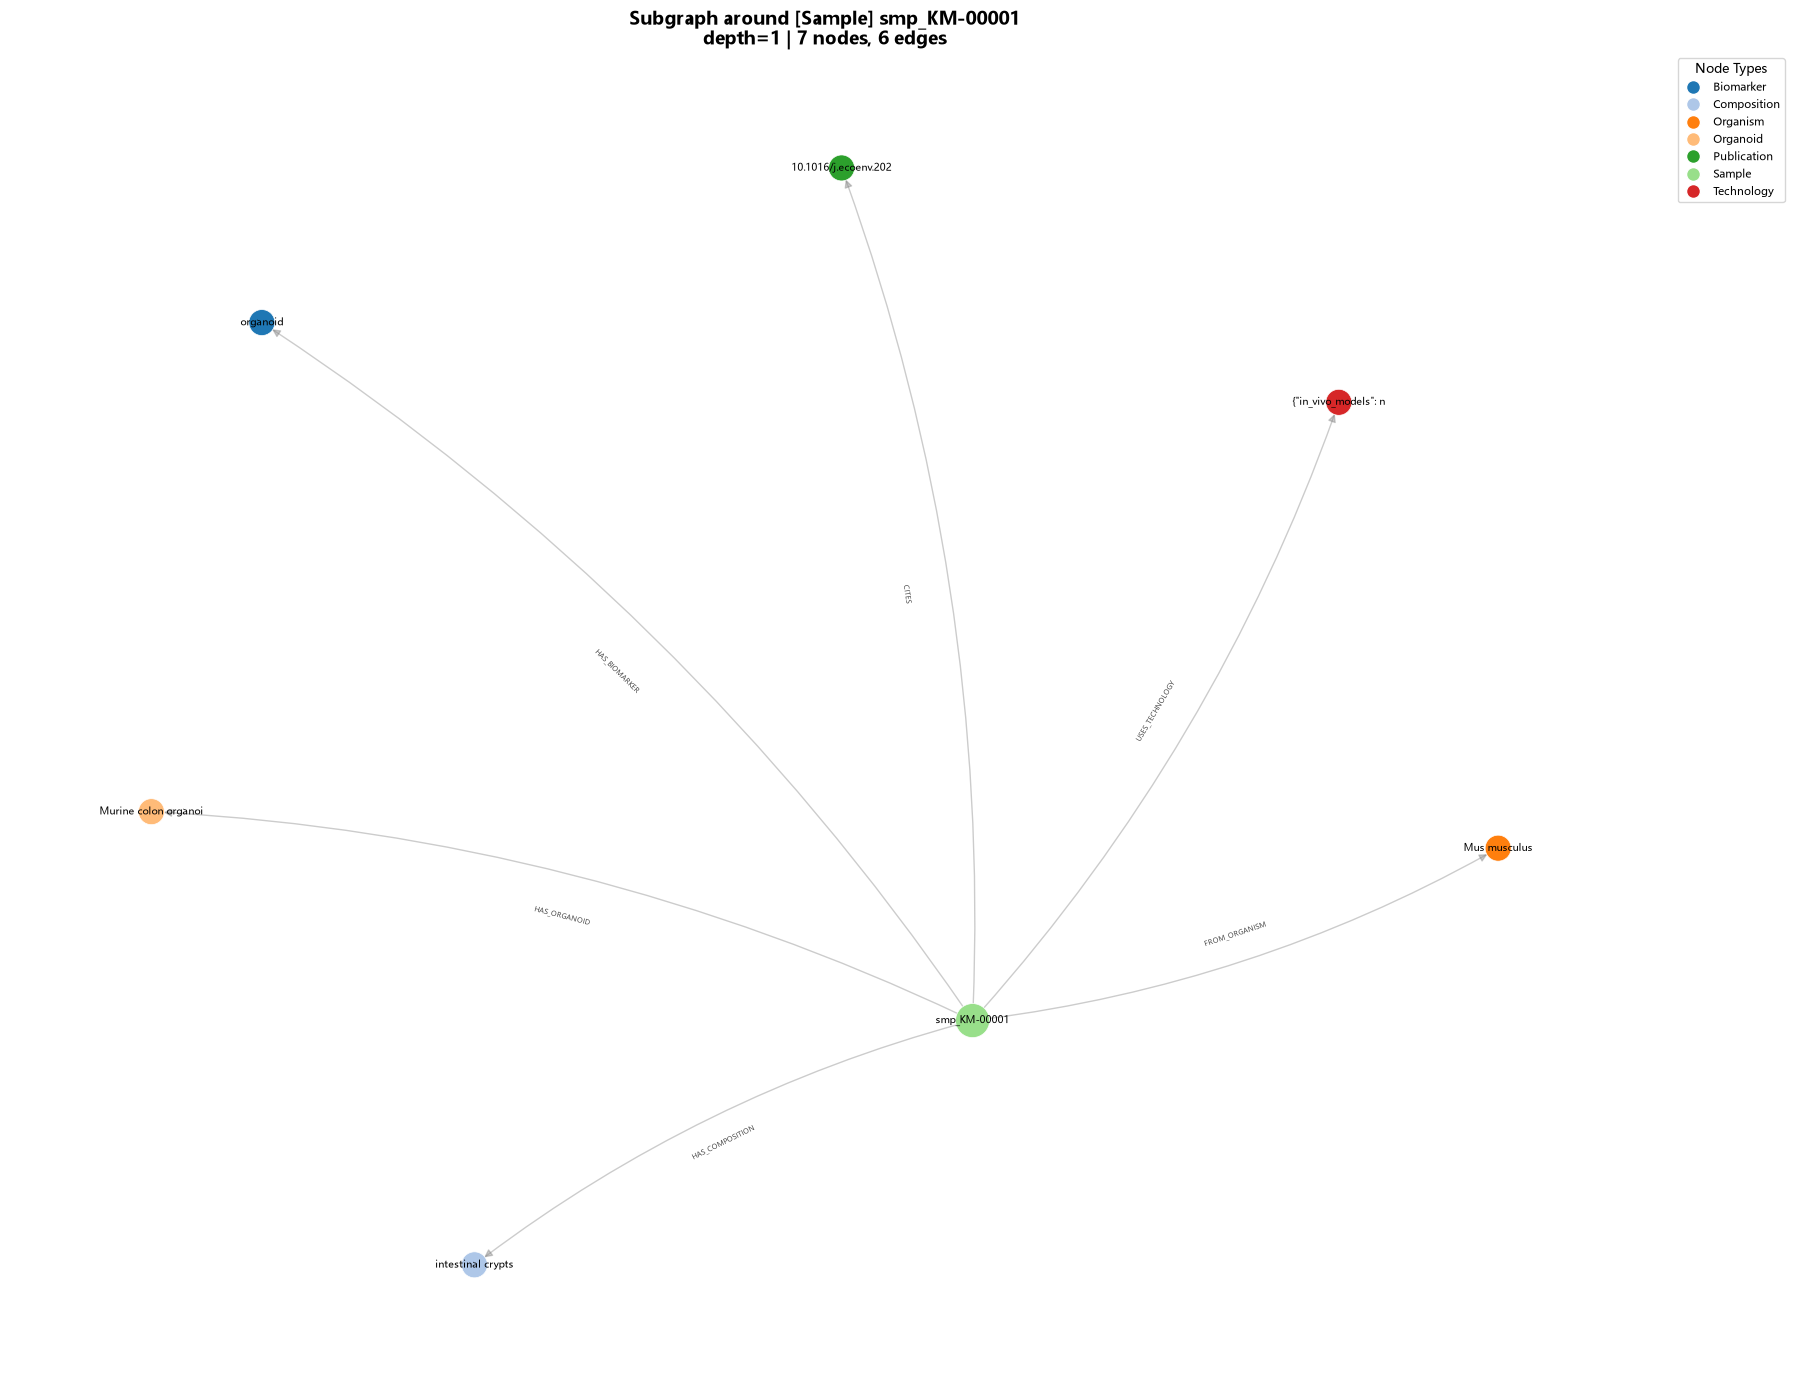

In [19]:
# Cell 3.3 — Visualize a subgraph with networkx
def visualize_subgraph(kg_obj, seed_node_id, depth=1, max_nodes=50, figsize=(16, 12)):
    """Build and render a networkx subgraph from a seed node."""
    if not HAS_NETWORKX or not HAS_MATPLOTLIB:
        print("This visualization requires matplotlib and networkx.")
        print("Install with: pip install matplotlib networkx")
        return

    sub = kg_obj.traverse(seed_node_id, depth=depth)
    sub_nodes = sub["nodes"][:max_nodes]
    sub_node_ids = {n.id for n in sub_nodes}
    sub_edges = [e for e in sub["edges"] if e.source in sub_node_ids and e.target in sub_node_ids]

    G = nx.DiGraph()
    for node in sub_nodes:
        name = node.properties.get("name", node.id)
        label = str(name)[:20] if name != node.id else node.id[:20]
        G.add_node(node.id, type=node.type, label=label)

    for edge in sub_edges:
        G.add_edge(edge.source, edge.target, relation=edge.relation)

    # Color map for node types
    all_types = sorted(set(nx.get_node_attributes(G, "type").values()))
    type_colors = {t: plt.cm.tab20(i % 20) for i, t in enumerate(all_types)}

    node_colors = [type_colors[G.nodes[n]["type"]] for n in G.nodes()]
    node_sizes = [300 + 50 * G.degree(n) for n in G.nodes()]

    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(G, k=3, seed=42, iterations=50)

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", alpha=0.4, arrows=True,
                           arrowsize=12, connectionstyle="arc3,rad=0.1")

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                           edgecolors="white", linewidths=0.5)

    labels = {n: G.nodes[n]["label"] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7)

    # Edge labels (only for small subgraphs)
    if len(sub_edges) <= 30:
        edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax, font_size=5, alpha=0.7)

    # Legend
    legend_handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=type_colors[t],
                                  markersize=10, label=t) for t in all_types]
    ax.legend(handles=legend_handles, title="Node Types", loc="upper left",
              bbox_to_anchor=(1.02, 1), fontsize=8, title_fontsize=9)

    seed_name = kg_obj.nodes[seed_node_id].properties.get("name", seed_node_id)
    ax.set_title(f"Subgraph around [{kg_obj.nodes[seed_node_id].type}] {seed_name}\n"
                 f"depth={depth} | {len(sub_nodes)} nodes, {len(sub_edges)} edges",
                 fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

if kg is not None:
    # Use the sample node from Cell 3.1 or pick any Sample
    sample_ids = kg._type_index.get("Sample", [])
    if sample_ids:
        seed = sample_ids[0]
        print(f"Visualizing subgraph around Sample: {seed}")
        visualize_subgraph(kg, seed, depth=1, max_nodes=VIZ_MAX_SUBGRAPH_NODES, figsize=(18, 14))
    else:
        print("No Sample nodes available.")
else:
    print("KG not loaded. Run Cell 1.2 first.")


In [20]:
# Cell 3.4 — Compare two samples' subgraphs
if kg is not None:
    sample_ids = kg._type_index.get("Sample", [])
    if len(sample_ids) >= 2:
        id_a, id_b = sample_ids[0], sample_ids[1]
        name_a = kg.nodes[id_a].properties.get("sample_id", id_a)
        name_b = kg.nodes[id_b].properties.get("sample_id", id_b)

        sub_a = kg.traverse(id_a, depth=1)
        sub_b = kg.traverse(id_b, depth=1)

        neighbors_a = {n.id for n in sub_a["nodes"] if n.id != id_a}
        neighbors_b = {n.id for n in sub_b["nodes"] if n.id != id_b}

        shared = neighbors_a & neighbors_b
        only_a = neighbors_a - neighbors_b
        only_b = neighbors_b - neighbors_a

        print(f"Sample A: {name_a}  →  {len(neighbors_a)} neighbors")
        print(f"Sample B: {name_b}  →  {len(neighbors_b)} neighbors")
        print(f"\nShared:  {len(shared)}")
        print(f"Only A:   {len(only_a)}")
        print(f"Only B:   {len(only_b)}")

        if len(neighbors_a | neighbors_b) > 0:
            jaccard = len(shared) / len(neighbors_a | neighbors_b)
            print(f"\nJaccard similarity: {jaccard:.3f}")

        # Shared entities by type
        shared_by_type = Counter(kg.nodes[nid].type for nid in shared)
        if shared_by_type:
            print(f"\nShared entities by type:")
            for t, c in shared_by_type.most_common(10):
                print(f"  [{t}] {c}")
    else:
        print("Need at least 2 Sample nodes. Found:", len(sample_ids))
else:
    print("KG not loaded. Run Cell 1.2 first.")


Sample A: KM-00001  →  6 neighbors
Sample B: KM-00002  →  15 neighbors

Shared:  2
Only A:   4
Only B:   13

Jaccard similarity: 0.105

Shared entities by type:
  [Biomarker] 1
  [Organism] 1


---
## Section 4: LLM-Powered GraphRAG Q&A

The **GraphRAG pipeline** (4 steps):
1. **Keyword search** — the question is split into keywords to find seed nodes
2. **LLM keyword extraction** (fallback) — if no results, the LLM extracts English keywords
3. **Subgraph traversal** — BFS from each seed node builds a context subgraph
4. **LLM generation** — evidence cards are injected into a prompt; the LLM answers based only on the graph

**Requires:** An API key for an OpenAI-compatible endpoint (DeepSeek, OpenAI, Ollama, vLLM).


In [21]:
# Cell 4.1 — Single-question GraphRAG demo
if kg is not None:
    # Resolve API key
    api_key = LLM_API_KEY or os.environ.get("DEEPSEEK_API_KEY") or os.environ.get("OPENAI_API_KEY")
    if not api_key:
        print("⚠  No API key configured.")
        print("   Set LLM_API_KEY in the Configuration cell, or set")
        print("   the DEEPSEEK_API_KEY / OPENAI_API_KEY environment variable.")
        print("\n   (Showing retrieval without LLM call as fallback.)\n")

        # Show what the retrieval would find
        question = "Which cell factor combinations are commonly used for intestinal organoid culture?"
        results = kg.search(question, top_k=10)
        print(f'Question: "{question}"')
        print(f"Retrieved {len(results)} seed nodes (without LLM):")
        for node, score in results[:10]:
            name = node.properties.get("name", node.properties.get("sample_id", node.id))
            print(f"  [{node.type}] {str(name)[:60]}  (score={score:.2f})")
    else:
        question = "Which cell factor combinations are commonly used for intestinal organoid culture?"
        print(f'Question: "{question}"\n')
        try:
            answer = kg.ask(
                question,
                api_key=api_key,
                base_url=LLM_BASE_URL,
                model=LLM_MODEL,
                top_k=DEFAULT_TOP_K,
                traversal_depth=DEFAULT_TRAVERSAL_DEPTH,
                verbose=True,
            )
            print(f"\n{'=' * 70}")
            print("RESPONSE:")
            print(f"{'=' * 70}")
            print(answer["response"])
            print(f"\n{'=' * 70}")
            print(f"Sources: {answer.get('sources', [])}")
            print(f"Subgraph: {answer.get('subgraph_stats', {})}")
        except Exception as e:
            print(f"[ERROR] {type(e).__name__}: {e}")
            import traceback
            traceback.print_exc()
else:
    print("KG not loaded. Run Cell 1.2 first.")


Question: "Which cell factor combinations are commonly used for intestinal organoid culture?"


[Search] Found 20 seed nodes:
  [Sample] smp_KM-02616 (score: 0.82)
  [Sample] smp_KM-07729 (score: 0.82)
  [Sample] smp_KM-12120 (score: 0.82)
  [Sample] smp_KM-IO-00409 (score: 0.82)
  [Sample] smp_KM-00116 (score: 0.73)
[Traverse] Subgraph: 20706 nodes, 240862 edges


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [22]:
# Cell 4.2 — Batch questions
if kg is not None:
    api_key = LLM_API_KEY or os.environ.get("DEEPSEEK_API_KEY") or os.environ.get("OPENAI_API_KEY")
    if not api_key:
        print("⚠  API key required for GraphRAG. Configure LLM_API_KEY in the Configuration cell.")
    else:
        questions = [
            "Which drugs have been screened on liver organoids?",
            "What phenotypes are observed in APC-edited organoids?",
            "Compare cell factors used in human vs mouse intestinal organoids",
        ]
        results_summary = []
        for q in questions:
            print(f"\n{'=' * 70}")
            print(f"Q: {q}")
            print(f"{'=' * 70}")
            try:
                ans = kg.ask(q, api_key=api_key, base_url=LLM_BASE_URL, model=LLM_MODEL,
                             top_k=DEFAULT_TOP_K, traversal_depth=1, verbose=False)
                response_preview = ans["response"][:200].replace("\n", " ")
                results_summary.append({
                    "Question": q[:80],
                    "Response len": len(ans["response"]),
                    "Subgraph nodes": ans.get("subgraph_stats", {}).get("nodes", "?"),
                    "Preview": response_preview + "...",
                })
                print(f"  → {response_preview}...")
            except Exception as e:
                print(f"  [ERROR] {type(e).__name__}: {e}")
                results_summary.append({"Question": q[:80], "Response len": 0, "Subgraph nodes": 0, "Preview": str(e)})

        # Summary table
        print(f"\n\n{'=' * 70}")
        print("BATCH SUMMARY")
        print(f"{'=' * 70}")
        if HAS_PANDAS:
            display(pd.DataFrame(results_summary))
        else:
            for r in results_summary:
                print(f"  [{r['Subgraph nodes']} nodes] {r['Question']}")
                print(f"    → {r['Preview'][:120]}")
else:
    print("KG not loaded. Run Cell 1.2 first.")



Q: Which drugs have been screened on liver organoids?
  → Based on the retrieved evidence, the following drugs have been screened on liver organoids:  ### From Primary Human Liver Cancer Organoid (smp_KM-06733) - cisplatin - gemcitabine - bortezomib - Ixazom...

Q: What phenotypes are observed in APC-edited organoids?
  → Based on the provided evidence, no samples with APC gene editing were found. The gene edits present in the retrieved subset are *Cdh1*, *JUN*, *PRPF31*, and *TSC1* — none of which are *APC*. Therefore...

Q: Compare cell factors used in human vs mouse intestinal organoids
  → Based on the provided samples, comparing cell factors used in human versus mouse intestinal organoids:  - **Mouse intestinal organoids** (Mus musculus)     - **smp_KM-08508** (Murine Small Intestinal ...


BATCH SUMMARY


,Question,Response len,Subgraph nodes,Preview
0,Which drugs have been screened on liver organo...,1159,253,"Based on the retrieved evidence, the following..."
1,What phenotypes are observed in APC-edited org...,307,227,"Based on the provided evidence, no samples wit..."
2,Compare cell factors used in human vs mouse in...,1736,171,"Based on the provided samples, comparing cell ..."


In [25]:
# Cell 4.3 — Question refinement demo (from chat.py)
if kg is not None:
    api_key = LLM_API_KEY or os.environ.get("DEEPSEEK_API_KEY") or os.environ.get("OPENAI_API_KEY")
    if not api_key:
        print("⚠  API key required. Configure LLM_API_KEY in the Configuration cell.")
    else:
        try:
            from chat import ChatSession, REFINE_SYSTEM_PROMPT

            print("Question refinement helps narrow down vague research questions.")
            print("The LLM analyzes your question against the KG schema and presents")
            print("specific search directions as multiple-choice options.\n")

            # Show the system prompt (abbreviated)
            print("─ System Prompt (abbreviated) ─")
            print(REFINE_SYSTEM_PROMPT[:600] + "...\n")

            # Demo with a vague question
            vague_q = "tell me about liver organoids"
            print(f"Vague question:  '{vague_q}'")
            print("\n(This is a demo — run chat.py for the full interactive experience.)")
            print("In chat.py, the LLM would respond with:\n")
            print("OPTIONS:")
            print("(a) List all liver organoid samples with their organoid types")
            print("(b) Drugs screened on liver organoids")
            print("(c) Gene edits used in liver organoids")
            print("(d) Phenotypes observed in liver organoids")
            print("(e) Other — please describe what you're looking for")
            print("\nAfter the user selects an option:")
            print("READY: Which liver organoid samples were screened with drugs? ...")

        except ImportError as e:
            print(f"[SKIPPED] Could not import from chat.py: {e}")
            print("[HINT] Make sure scripts/chat.py exists and scripts/ is in sys.path.")
else:
    print("KG not loaded. Run Cell 1.2 first.")


Question refinement helps narrow down vague research questions.
The LLM analyzes your question against the KG schema and presents
specific search directions as multiple-choice options.

─ System Prompt (abbreviated) ─
You help users narrow down vague research questions about an organoid knowledge graph.

## Knowledge Graph Schema

The graph has 18 node types connected by 19 relationship types:

### Node Types
- Sample (smp_): An experiment record — the central hub. Properties: sample_id, culture_days, organ, organism.
- Organoid (org_): A standardized organoid type (e.g. "Intestinal Organoid", "Hepatic Organoid").
- Organ (orn_): The organ/tissue of origin (e.g. "Liver", "Small Intestine", "Brain").
- System (sys_): Physiological system (e.g. "Digestive System", "Nervous System").
- Organism (osm_): Species...

Vague question:  'tell me about liver organoids'

(This is a demo — run chat.py for the full interactive experience.)
In chat.py, the LLM would respond with:

OPTIONS:
(a) List 

---
## Section 5: Appendix — Reference Tables & Troubleshooting


### 5.1 — Node Types Reference

| Node Type | ID Prefix | Description | Example Entity |
|-----------|-----------|-------------|----------------|
| **Sample** | `smp_` | Core experiment record; central hub of the KG | `smp_KM-00001` |
| **Organoid** | `org_` | Standardized organoid type | Intestinal Organoid, Hepatic Organoid |
| **Organ** | `orn_` | Organ or tissue of origin | Liver, Small Intestine, Brain |
| **System** | `sys_` | Physiological system | Digestive System, Nervous System |
| **Organism** | `osm_` | Species | Homo sapiens, Mus musculus |
| **Source** | `src_` | Tissue or cell origin source | Patient-derived, iPSC |
| **CellFactor** | `cf_` | Growth factors / small molecules | EGF, Wnt3a, Noggin, R-spondin |
| **Technology** | `tec_` | Culture or analysis technologies | CRISPR, scRNA-seq, Organ-on-chip |
| **Drug** | `drg_` | Screened drugs | Cisplatin, Urolithin A |
| **Gene** | `gen_` | Gene editing targets | APC, TP53, KRAS |
| **DiseaseModel** | `dm_` | Disease models | Colorectal Cancer, IBD, AD |
| **Infection** | `inf_` | Infection challenge agents | H1N1, SARS-CoV-2 |
| **Biomarker** | `bmk_` | Biomarkers | Lgr5, Ki67, E-cadherin |
| **Phenotype** | `phn_` | Observed phenotypes | increased senescence, budding |
| **Omics** | `omc_` | Omics datasets | scRNA-seq, GEO accession |
| **Composition** | `cmp_` | Cell composition profiles | mixed cell types |
| **Application** | `app_` | Application directions | Drug Screening, Disease Modeling |
| **Publication** | `pub_` | Cited references (by DOI) | 10.1038/xxx |


### 5.2 — Relationship Types Reference

| Relation | Direction | Description | Type |
|----------|-----------|-------------|------|
| `HAS_ORGANOID` | Sample → Organoid | Sample uses an organoid type | Direct |
| `FROM_ORGAN` | Organoid → Organ | Organoid originates from an organ | Direct |
| `BELONGS_TO_SYSTEM` | Organ → System | Organ belongs to a physiological system | Direct |
| `FROM_ORGANISM` | Sample → Organism | Sample's species | Direct |
| `DERIVED_FROM` | Organoid → Source | Organoid's tissue source | Direct |
| `USES_FACTOR` | Sample → CellFactor | Culture media growth factor | Direct |
| `USES_TECHNOLOGY` | Sample → Technology | Technology used in experiment | Direct |
| `SCREENS_DRUG` | Sample → Drug | Drug screened in this sample | Direct |
| `HAS_GENE_EDIT` | Sample → Gene | Gene edited in this sample | Direct |
| `MODELS_DISEASE` | Organoid → DiseaseModel | Disease modeled by the organoid | Direct |
| `HAS_INFECTION` | Sample → Infection | Infection challenge applied | Direct |
| `HAS_BIOMARKER` | Sample → Biomarker | Biomarker measured | Direct |
| `HAS_PHENOTYPE` | Sample → Phenotype | Phenotype observed | Direct |
| `HAS_OMICS` | Sample → Omics | Omics data generated | Direct |
| `HAS_COMPOSITION` | Sample → Composition | Cell composition profile | Direct |
| `HAS_APPLICATION` | Organoid → Application | Application area | Direct |
| `CITES` | Sample → Publication | Reference cited | Direct |
| `TREATS_DISEASE` | Drug → DiseaseModel | Drug treats a disease (co-occurrence) | **Inferred** (confidence=0.5) |
| `INDICATES_DISEASE` | Biomarker → DiseaseModel | Biomarker indicates a disease (co-occurrence) | **Inferred** (confidence=0.5) |

**Note:** Inferred relationships are generated from co-occurrence within the same sample.
They carry `confidence: 0.5` and are marked with `[inferred]` in GraphRAG answers.


### 5.3 — Troubleshooting & Tips

#### Knowledge Graph Loading
- **"MemoryError loading JSON"** → The JSON file can be ~560 MB. Use the **SQLite format** instead:
  set `KG_SQLITE_PATH` to the `.sqlite` file path. SQLite loads incrementally and uses less memory.
- **"File not found"** → Set `KG_JSON_PATH` or `KG_SQLITE_PATH` explicitly in the Configuration cell,
  or place your KG file under the `KG_OUTPUT_DIR` directory.

#### API Keys (for GraphRAG)
- **DeepSeek**: Set `LLM_API_KEY` or the `DEEPSEEK_API_KEY` env var. Base URL: `https://api.deepseek.com`
- **OpenAI**: Set `LLM_API_KEY` or the `OPENAI_API_KEY` env var. Base URL: `https://api.openai.com/v1`
- **Ollama (local)**: No key needed. Set `LLM_BASE_URL="http://localhost:11434/v1"`, `LLM_MODEL="llama3"`
- **"Rate limit"** → Wait and retry, or switch to a different provider.

#### Visualization
- **Chinese characters show as ▯** → Install a CJK font or set `plt.rcParams["font.sans-serif"]` to an available font.
- **"No module named 'matplotlib'"** → `pip install matplotlib networkx`
- **Subgraph too dense** → Reduce `VIZ_MAX_SUBGRAPH_NODES` or decrease traversal depth.

#### Export & Sharing
- **Export to HTML**: `jupyter nbconvert --to html orbit_kg_notebook.ipynb`
- **Export to PDF**: `jupyter nbconvert --to pdf orbit_kg_notebook.ipynb`
- **Clear all outputs before sharing**: `jupyter nbconvert --clear-output orbit_kg_notebook.ipynb`

#### Further Reading
- `tutorial.md` — Full tutorial (Chinese) covering methodology, schema, build, and distribution
- `schema_design.md` — Detailed KG schema with field definitions
